# CSD-Based Model Routing Simulation: Downstream Value Quantification

This notebook demonstrates a Monte Carlo simulation of CSD-based model routing across two task domains:
- **Arithmetic** (3 LLMs, 24 difficulty levels)
- **Graph Coloring** (3 LLMs, 20 difficulty levels)

It compares **4 routing policies** (always-cheap, always-capable, CSD-monitored, oracle) to quantify
accuracy-vs-cost tradeoffs. The CSD monitoring policy uses a multi-indicator CUSUM alarm
(variance + disagreement + dip) that detects capability degradation several levels before the
critical difficulty threshold d*.

**Key finding**: CSD routing captures ~54% of oracle improvement at ~59% of capable-model cost.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed — all imports are stdlib + numpy + matplotlib

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import time
from collections import defaultdict
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/evaluation_iter6_csd_based_model/demo/mini_demo_data.json"

def load_data():
    """Load mini demo data from GitHub (primary) or local fallback."""
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with {len(data['tasks'])} tasks:")
for task_name, task_info in data["tasks"].items():
    models = task_info["models"]
    print(f"  {task_name}: {len(models)} models")
    for m, info in models.items():
        print(f"    {m}: {len(info['levels'])} levels, d*={info['d_star']}")

Loaded data with 2 tasks:
  arithmetic: 3 models
    llama-3.1-8b-instruct: 24 levels, d*=20
    gemini-2.0-flash-001: 24 levels, d*=15
    gpt-4o-mini: 24 levels, d*=2
  graph_coloring: 3 models
    gpt-4o-mini: 20 levels, d*=10
    gemini-2.0-flash-001: 20 levels, d*=14
    gemini-2.0-flash-lite-001: 20 levels, d*=11


## Configuration

All tunable simulation parameters. Start with minimum values for fast iteration.

In [5]:
# ── Simulation parameters ──
N_QUERIES = 1000            # queries per MC run
N_MC_RUNS = 100             # Monte Carlo runs per policy
BATCH_SIZES = [10, 15, 20, 30, 50]  # CSD sampling batch sizes
DIFFICULTY_DISTRIBUTIONS = ["uniform", "beta_easy", "beta_hard"]

# ── Cost model ──
COST_CHEAP = 0.001          # $/query for cheap model
COST_CAPABLE = 0.010        # $/query for capable model

# ── CSD alarm parameters ──
CSD_ALARM_THRESHOLD = 1.3   # alarm fires when variance > baseline * threshold
CSD_ALARM_MIN_LEVELS = 3    # need at least 3 levels to establish baseline

# ── Policies to compare ──
POLICIES = ["always_cheap", "always_capable", "oracle", "csd_monitoring"]

## Extract Model Data

Convert loaded JSON into per-model dictionaries with integer-keyed levels (matching the original `load_arithmetic_data` / `load_graph_coloring_data` output format).

In [6]:
# Build task configurations from loaded data
# Convert string keys to int keys for levels (JSON stores keys as strings)
tasks = []
for task_name, task_info in data["tasks"].items():
    models = {}
    for model_name, model_data in task_info["models"].items():
        levels = {int(k): v for k, v in model_data["levels"].items()}
        models[model_name] = {"levels": levels, "d_star": model_data["d_star"]}
    tasks.append({
        "name": task_name,
        "models": models,
        "cheap": task_info["cheap_model"],
        "capable": task_info["capable_model"],
    })

for t in tasks:
    cheap_d = t["models"][t["cheap"]]["d_star"]
    cap_d = t["models"][t["capable"]]["d_star"]
    print(f"Task: {t['name']} | cheap={t['cheap']} (d*={cheap_d}) | capable={t['capable']} (d*={cap_d})")

Task: arithmetic | cheap=gemini-2.0-flash-001 (d*=15) | capable=llama-3.1-8b-instruct (d*=20)
Task: graph_coloring | cheap=gemini-2.0-flash-lite-001 (d*=11) | capable=gemini-2.0-flash-001 (d*=14)


## CSD Alarm Function

Multi-indicator CUSUM alarm using three channels:
1. **Variance CUSUM** -- detects upward shift in embedding response diversity
2. **Disagreement rate CUSUM** -- exceeding baseline threshold
3. **Dip-based bimodality** -- significant dip test with elevated variance

Sampling noise is scaled by `1/sqrt(batch_size)` to model the effect of smaller batches on indicator reliability.

In [7]:
def compute_csd_alarm_level(
    cheap_indicators: dict[int, dict],
    sorted_levels: list[int],
    batch_size: int,
    rng: np.random.Generator,
) -> int | None:
    """Multi-indicator CSD alarm using variance CUSUM + disagreement rate.

    Uses three alarm channels (first to trigger wins):
    1. CUSUM on embedding variance (detects upward shift in response diversity)
    2. Disagreement rate exceeding baseline * threshold
    3. Dip-significant bimodality with elevated variance

    Returns difficulty level where alarm fires, or None if never fires.
    """
    if len(sorted_levels) < CSD_ALARM_MIN_LEVELS + 1:
        return None

    # Collect noisy observations for all indicators
    obs_var: dict[int, float] = {}
    obs_disagr: dict[int, float] = {}
    obs_dip_p: dict[int, float] = {}

    noise_factor = 1.0 / math.sqrt(max(batch_size, 2))

    for d in sorted_levels:
        ind = cheap_indicators.get(d, {})

        # Variance with noise
        true_var = ind.get("csd_variance", 0.1)
        obs_var[d] = max(true_var + rng.normal(0, true_var * noise_factor * 0.3), 0.001)

        # Disagreement rate with noise
        true_dis = ind.get("disagreement_rate", 0.5)
        obs_disagr[d] = np.clip(true_dis + rng.normal(0, 0.05 * noise_factor), 0.0, 1.0)

        # Dip p-value (smaller batch = less power)
        true_dip_p = ind.get("dip_pvalue", 1.0)
        if true_dip_p is None:
            true_dip_p = 1.0
        power_adj = math.sqrt(50.0 / max(batch_size, 2))
        obs_dip_p[d] = min(true_dip_p * power_adj, 1.0)

    # Baselines from first few levels
    bl = sorted_levels[:CSD_ALARM_MIN_LEVELS]

    # Variance CUSUM baseline
    var_bl = [obs_var[d] for d in bl]
    var_target = float(np.mean(var_bl))
    var_std = max(float(np.std(var_bl)), var_target * 0.03)

    # Disagreement rate baseline
    dis_bl = [obs_disagr[d] for d in bl]
    dis_target = float(np.mean(dis_bl))
    dis_std = max(float(np.std(dis_bl)), 0.03)

    # CUSUM state
    cusum_var = 0.0
    cusum_h_var = 2.5 * var_std
    allow_var = 0.5 * var_std

    # Disagreement CUSUM state
    cusum_dis = 0.0
    cusum_h_dis = 2.5 * dis_std
    allow_dis = 0.5 * dis_std

    for d in sorted_levels[CSD_ALARM_MIN_LEVELS:]:
        # Channel 1: Variance CUSUM
        cusum_var = max(0.0, cusum_var + obs_var[d] - var_target - allow_var)
        if cusum_var > cusum_h_var:
            return d

        # Channel 2: Disagreement CUSUM
        cusum_dis = max(0.0, cusum_dis + obs_disagr[d] - dis_target - allow_dis)
        if cusum_dis > cusum_h_dis:
            return d

        # Channel 3: Dip-based bimodality + elevated variance
        if obs_dip_p[d] < 0.05 and obs_var[d] > var_target * 1.05:
            return d

    return None

## Monte Carlo Simulation Helpers

Helper functions for mapping difficulties and running individual MC simulation runs.

In [8]:
def _nearest_level(difficulty_val: int, sorted_levels: list[int]) -> int:
    """Map an integer difficulty to the nearest available level."""
    idx = np.searchsorted(sorted_levels, difficulty_val)
    if idx == 0:
        return sorted_levels[0]
    if idx >= len(sorted_levels):
        return sorted_levels[-1]
    lo, hi = sorted_levels[idx - 1], sorted_levels[idx]
    return lo if abs(difficulty_val - lo) <= abs(difficulty_val - hi) else hi


def generate_difficulties(
    rng: np.random.Generator,
    dist_name: str,
    n: int,
    min_level: int,
    max_level: int,
) -> np.ndarray:
    """Generate n query difficulty values from the specified distribution."""
    if dist_name == "uniform":
        raw = rng.uniform(0, 1, n)
    elif dist_name == "beta_easy":
        raw = rng.beta(2, 5, n)
    elif dist_name == "beta_hard":
        raw = rng.beta(5, 2, n)
    else:
        raw = rng.uniform(0, 1, n)

    scaled = np.round(raw * (max_level - min_level) + min_level).astype(int)
    return np.clip(scaled, min_level, max_level)


def run_single_mc(
    mc_idx, policy_name, cheap_levels, capable_levels,
    cheap_indicators, sorted_levels, d_star_cheap,
    batch_size, dist_name, seed,
) -> dict:
    """Run a single Monte Carlo simulation for a given policy + parameters."""
    rng = np.random.default_rng(seed)
    min_level = sorted_levels[0]
    max_level = sorted_levels[-1]

    # Generate query difficulties
    difficulties = generate_difficulties(rng, dist_name, N_QUERIES, min_level, max_level)

    # Compute CSD alarm level (only relevant for csd_monitoring)
    alarm_level = None
    if policy_name == "csd_monitoring":
        alarm_level = compute_csd_alarm_level(
            cheap_indicators, sorted_levels, batch_size, rng,
        )

    # Simulate queries
    n_correct = 0
    total_cost = 0.0
    n_cheap = 0
    n_capable = 0

    for d_raw in difficulties:
        d_int = int(d_raw)
        d_mapped = _nearest_level(d_int, sorted_levels)

        cheap_acc = cheap_levels.get(d_mapped, {}).get("accuracy", 0.0)
        cap_acc = capable_levels.get(d_mapped, {}).get("accuracy", 0.0)

        # Routing decision
        if policy_name == "always_cheap":
            use_capable = False
        elif policy_name == "always_capable":
            use_capable = True
        elif policy_name == "oracle":
            use_capable = cap_acc > cheap_acc
        elif policy_name == "csd_monitoring":
            use_capable = alarm_level is not None and d_int >= alarm_level
        else:
            use_capable = False

        # Determine outcome
        acc = cap_acc if use_capable else cheap_acc
        cost = COST_CAPABLE if use_capable else COST_CHEAP
        correct = rng.random() < acc
        n_correct += int(correct)
        total_cost += cost
        if use_capable:
            n_capable += 1
        else:
            n_cheap += 1

    # CSD monitoring overhead: sampling B responses at each level up to alarm
    csd_overhead = 0.0
    n_levels_monitored = 0
    if policy_name == "csd_monitoring":
        if alarm_level is None:
            n_levels_monitored = len(sorted_levels)
        else:
            n_levels_monitored = len([lv for lv in sorted_levels if lv <= alarm_level])
        csd_overhead = n_levels_monitored * batch_size * COST_CHEAP
        total_cost += csd_overhead

    accuracy = n_correct / N_QUERIES
    return {
        "mc_idx": mc_idx,
        "policy": policy_name,
        "accuracy": accuracy,
        "error_rate": 1.0 - accuracy,
        "total_cost": total_cost,
        "csd_overhead": csd_overhead,
        "n_correct": n_correct,
        "n_cheap": n_cheap,
        "n_capable": n_capable,
        "alarm_level": alarm_level,
        "n_levels_monitored": n_levels_monitored,
        "batch_size": batch_size,
        "dist_name": dist_name,
    }

## Metrics Computation

Aggregate metrics for each policy: accuracy, cost, error reduction, oracle gap, Pareto optimality, and breakeven analysis.

In [9]:
def _ci95(values: list[float]) -> float:
    """95% confidence interval half-width."""
    if len(values) < 2:
        return 0.0
    return float(1.96 * np.std(values, ddof=1) / math.sqrt(len(values)))


def _oracle_gap(policy_acc: float, cheap_acc: float, oracle_acc: float) -> float:
    """Oracle gap: fraction of oracle's improvement captured by this policy."""
    denom = oracle_acc - cheap_acc
    if abs(denom) < 1e-10:
        return 0.0
    return float((policy_acc - cheap_acc) / denom * 100)


def is_pareto_optimal(
    acc: float, cost: float, all_points: list[tuple[float, float]],
) -> bool:
    """Check if (acc, cost) is on the Pareto frontier (higher acc, lower cost)."""
    for a, c in all_points:
        if a >= acc and c <= cost and (a > acc or c < cost):
            return False
    return True


def compute_breakeven(
    csd_results: list[dict],
    capable_results: list[dict],
) -> float:
    """Minimum query volume where CSD routing beats always-capable on cost."""
    overheads = [r["csd_overhead"] for r in csd_results]
    mean_overhead = float(np.mean(overheads))

    csd_total_no_overhead = [r["total_cost"] - r["csd_overhead"] for r in csd_results]
    csd_per_query = float(np.mean(csd_total_no_overhead)) / N_QUERIES

    cap_per_query = float(np.mean([r["total_cost"] for r in capable_results])) / N_QUERIES

    savings_per_query = cap_per_query - csd_per_query
    if savings_per_query <= 1e-10:
        return float("inf")

    breakeven = mean_overhead / savings_per_query
    return max(breakeven, 1.0)


def compute_policy_metrics(
    mc_results: list[dict],
    cheap_results: list[dict],
    capable_results: list[dict],
    oracle_results: list[dict],
    d_star_cheap: int | None,
) -> dict[str, Any]:
    """Compute aggregate metrics for a policy from its MC results."""
    accuracies = [r["accuracy"] for r in mc_results]
    costs = [r["total_cost"] for r in mc_results]
    error_rates = [r["error_rate"] for r in mc_results]

    cheap_mean_err = float(np.mean([r["error_rate"] for r in cheap_results]))
    capable_mean_cost = float(np.mean([r["total_cost"] for r in capable_results]))
    cheap_mean_cost = float(np.mean([r["total_cost"] for r in cheap_results]))
    oracle_mean_acc = float(np.mean([r["accuracy"] for r in oracle_results]))
    cheap_mean_acc = float(np.mean([r["accuracy"] for r in cheap_results]))

    mean_acc = float(np.mean(accuracies))
    mean_cost = float(np.mean(costs))
    mean_err = float(np.mean(error_rates))

    # Error reduction vs cheap
    if cheap_mean_err > 1e-10:
        error_reduction = (cheap_mean_err - mean_err) / cheap_mean_err * 100
    else:
        error_reduction = 0.0

    # Cost relative to capable
    cost_relative = mean_cost / max(capable_mean_cost, 1e-10) * 100

    # Cost efficiency ratio: errors avoided per dollar extra
    extra_cost = mean_cost - cheap_mean_cost
    errors_avoided = cheap_mean_err - mean_err
    if extra_cost > 1e-6:
        cost_efficiency = errors_avoided / extra_cost
    else:
        cost_efficiency = 0.0

    # Oracle gap
    oracle_gap = _oracle_gap(mean_acc, cheap_mean_acc, oracle_mean_acc)

    # Alarm-level metrics (CSD monitoring only)
    alarm_levels = [r["alarm_level"] for r in mc_results if r["alarm_level"] is not None]
    if alarm_levels and d_star_cheap is not None:
        mean_alarm = float(np.mean(alarm_levels))
        alarm_lead_times = [d_star_cheap - a for a in alarm_levels]
        mean_lead = float(np.mean(alarm_lead_times))
        lead_pos_frac = float(sum(1 for t in alarm_lead_times if t > 0) / len(alarm_lead_times))
    else:
        mean_alarm = -1.0
        mean_lead = 0.0
        lead_pos_frac = 0.0

    return {
        "mean_accuracy": mean_acc,
        "ci95_accuracy": _ci95(accuracies),
        "mean_cost": mean_cost,
        "ci95_cost": _ci95(costs),
        "mean_error_rate": mean_err,
        "error_reduction_vs_cheap": error_reduction,
        "cost_relative_to_capable": cost_relative,
        "cost_efficiency_ratio": cost_efficiency,
        "oracle_gap": oracle_gap,
        "mean_alarm_level": mean_alarm,
        "mean_alarm_lead_time": mean_lead,
        "alarm_lead_pos_frac": lead_pos_frac,
    }

## Run Simulation

Main loop: for each task, run Monte Carlo simulations across all policy x batch-size x distribution combinations. Results are collected sequentially (the original uses `ProcessPoolExecutor` for parallelism).

In [10]:
t0 = time.time()
print("Starting CSD-Based Model Routing Simulation\n")

all_task_results = {}  # task_name -> {dist -> {batch -> {policy -> metrics}}}
all_task_breakevens = {}

for task_cfg in tasks:
    task_name = task_cfg["name"]
    cheap_name = task_cfg["cheap"]
    capable_name = task_cfg["capable"]
    models = task_cfg["models"]

    cheap_data = models[cheap_name]
    capable_data = models[capable_name]
    d_star_cheap = cheap_data["d_star"]

    # Build sorted level list (union of both models)
    all_levels_set = set(cheap_data["levels"].keys()) | set(capable_data["levels"].keys())
    sorted_levels = sorted(all_levels_set)

    cheap_indicators = cheap_data["levels"]

    print(f"=== Task: {task_name} ===")
    print(f"  Cheap: {cheap_name} (d*={d_star_cheap})")
    print(f"  Capable: {capable_name} (d*={capable_data['d_star']})")
    print(f"  Levels: {sorted_levels[0]}..{sorted_levels[-1]} ({len(sorted_levels)} levels)")

    task_results = {}

    for dist_name in DIFFICULTY_DISTRIBUTIONS:
        task_results[dist_name] = {}
        for batch_size in BATCH_SIZES:
            base_seed = abs(hash((task_name, dist_name, batch_size))) % (2**31)

            # Run MC for all policies sequentially (notebook-friendly)
            results_by_policy: dict[str, list[dict]] = defaultdict(list)
            for pi, policy in enumerate(POLICIES):
                for mc_idx in range(N_MC_RUNS):
                    seed = base_seed + mc_idx + pi * N_MC_RUNS * 2
                    res = run_single_mc(
                        mc_idx, policy,
                        cheap_data["levels"], capable_data["levels"],
                        cheap_indicators, sorted_levels, d_star_cheap,
                        batch_size, dist_name, seed,
                    )
                    results_by_policy[res["policy"]].append(res)

            # Compute per-policy metrics
            cheap_res = results_by_policy["always_cheap"]
            capable_res = results_by_policy["always_capable"]
            oracle_res = results_by_policy["oracle"]
            csd_res = results_by_policy["csd_monitoring"]

            policy_metrics = {}
            for policy in POLICIES:
                policy_metrics[policy] = compute_policy_metrics(
                    results_by_policy[policy],
                    cheap_res, capable_res, oracle_res,
                    d_star_cheap,
                )

            # Pareto optimality
            points = [
                (policy_metrics[p]["mean_accuracy"], policy_metrics[p]["mean_cost"])
                for p in POLICIES
            ]
            for i, policy in enumerate(POLICIES):
                policy_metrics[policy]["pareto_optimal"] = is_pareto_optimal(
                    points[i][0], points[i][1], points,
                )

            # Breakeven
            breakeven_n = compute_breakeven(csd_res, capable_res)

            task_results[dist_name][batch_size] = policy_metrics
            all_task_breakevens[(task_name, dist_name, batch_size)] = breakeven_n

            # Print summary
            print(f"\n  B={batch_size} dist={dist_name}:")
            for p in POLICIES:
                pm = policy_metrics[p]
                alarm_str = ""
                if p == "csd_monitoring" and pm["mean_alarm_level"] > 0:
                    alarm_str = f" alarm_d={pm['mean_alarm_level']:.1f}"
                print(f"    {p:18s}: acc={pm['mean_accuracy']:.3f}  "
                      f"cost=${pm['mean_cost']:.3f}  "
                      f"OG={pm['oracle_gap']:.1f}%{alarm_str}")

    all_task_results[task_name] = task_results

elapsed = time.time() - t0
print(f"\nSimulation completed in {elapsed:.1f}s")

Starting CSD-Based Model Routing Simulation

=== Task: arithmetic ===
  Cheap: gemini-2.0-flash-001 (d*=15)
  Capable: llama-3.1-8b-instruct (d*=20)
  Levels: 2..25 (24 levels)



  B=10 dist=uniform:
    always_cheap      : acc=0.592  cost=$1.000  OG=0.0%
    always_capable    : acc=0.688  cost=$10.000  OG=81.1%
    oracle            : acc=0.711  cost=$8.061  OG=100.0%
    csd_monitoring    : acc=0.624  cost=$4.463  OG=26.7% alarm_d=7.2



  B=15 dist=uniform:
    always_cheap      : acc=0.593  cost=$1.000  OG=0.0%
    always_capable    : acc=0.689  cost=$10.000  OG=80.8%
    oracle            : acc=0.712  cost=$8.035  OG=100.0%
    csd_monitoring    : acc=0.625  cost=$4.511  OG=26.5% alarm_d=7.3



  B=20 dist=uniform:
    always_cheap      : acc=0.592  cost=$1.000  OG=0.0%
    always_capable    : acc=0.687  cost=$10.000  OG=81.1%
    oracle            : acc=0.709  cost=$8.046  OG=100.0%
    csd_monitoring    : acc=0.623  cost=$4.234  OG=26.4% alarm_d=6.9



  B=30 dist=uniform:
    always_cheap      : acc=0.592  cost=$1.000  OG=0.0%
    always_capable    : acc=0.688  cost=$10.000  OG=81.3%
    oracle            : acc=0.710  cost=$8.057  OG=100.0%
    csd_monitoring    : acc=0.618  cost=$3.784  OG=21.5% alarm_d=6.7


...


  B=10 dist=beta_hard:
    always_cheap      : acc=0.432  cost=$1.000  OG=0.0%
    always_capable    : acc=0.595  cost=$10.000  OG=94.6%
    oracle            : acc=0.605  cost=$8.707  OG=100.0%
    csd_monitoring    : acc=0.594  cost=$10.027  OG=93.8% alarm_d=5.7



  B=15 dist=beta_hard:
    always_cheap      : acc=0.428  cost=$1.000  OG=0.0%
    always_capable    : acc=0.593  cost=$10.000  OG=94.2%
    oracle            : acc=0.603  cost=$8.699  OG=100.0%
    csd_monitoring    : acc=0.594  cost=$10.061  OG=94.9% alarm_d=5.7



  B=20 dist=beta_hard:
    always_cheap      : acc=0.430  cost=$1.000  OG=0.0%
    always_capable    : acc=0.597  cost=$10.000  OG=95.5%
    oracle            : acc=0.605  cost=$8.712  OG=100.0%
    csd_monitoring    : acc=0.594  cost=$10.088  OG=93.9% alarm_d=5.8



  B=30 dist=beta_hard:
    always_cheap      : acc=0.429  cost=$1.000  OG=0.0%
    always_capable    : acc=0.597  cost=$10.000  OG=95.4%
    oracle            : acc=0.605  cost=$8.713  OG=100.0%
    csd_monitoring    : acc=0.596  cost=$10.145  OG=95.3% alarm_d=6.0



  B=50 dist=beta_hard:
    always_cheap      : acc=0.431  cost=$1.000  OG=0.0%
    always_capable    : acc=0.595  cost=$10.000  OG=95.3%
    oracle            : acc=0.604  cost=$8.701  OG=100.0%
    csd_monitoring    : acc=0.598  cost=$10.267  OG=96.6% alarm_d=6.0

Simulation completed in 31.3s


## Results Summary

Aggregate metrics table and cost-vs-accuracy visualization across all tasks and policies.

In [11]:
# ── Summary Table ──
print("=" * 80)
print("POLICY COMPARISON SUMMARY")
print("=" * 80)

for task_name, task_results in all_task_results.items():
    print(f"\n--- {task_name.upper()} ---")
    # Use first dist/batch for summary
    dist0 = DIFFICULTY_DISTRIBUTIONS[0]
    batch0 = BATCH_SIZES[0]
    pm = task_results[dist0][batch0]

    headers = ["Policy", "Accuracy", "Cost ($)", "Error Red. (%)", "Oracle Gap (%)", "Pareto"]
    rows = []
    for p in POLICIES:
        m = pm[p]
        rows.append([
            p,
            f"{m['mean_accuracy']:.4f} +/- {m['ci95_accuracy']:.4f}",
            f"{m['mean_cost']:.4f}",
            f"{m['error_reduction_vs_cheap']:.1f}",
            f"{m['oracle_gap']:.1f}",
            "Yes" if m["pareto_optimal"] else "No",
        ])
    print(tabulate(rows, headers=headers, tablefmt="grid"))

    # CSD alarm details
    csd_m = pm["csd_monitoring"]
    if csd_m["mean_alarm_level"] > 0:
        print(f"\n  CSD Alarm: fires at d={csd_m['mean_alarm_level']:.1f}, "
              f"lead time={csd_m['mean_alarm_lead_time']:.1f} levels, "
              f"reliability={csd_m['alarm_lead_pos_frac']*100:.0f}%")

    bk = all_task_breakevens.get((task_name, dist0, batch0), float("inf"))
    if bk < 1e7:
        print(f"  Breakeven: CSD beats always-capable after {bk:.0f} queries")

# ── Cross-task headline ──
print("\n" + "=" * 80)
oracle_gaps = []
cost_rels = []
for task_name, task_results in all_task_results.items():
    dist0 = DIFFICULTY_DISTRIBUTIONS[0]
    batch0 = BATCH_SIZES[0]
    csd_m = task_results[dist0][batch0]["csd_monitoring"]
    oracle_gaps.append(csd_m["oracle_gap"])
    cost_rels.append(csd_m["cost_relative_to_capable"])

avg_og = np.mean(oracle_gaps)
avg_cost = np.mean(cost_rels)
print(f"HEADLINE: CSD routing achieves {avg_og:.1f}% of oracle improvement "
      f"at {avg_cost:.1f}% of capable cost")

POLICY COMPARISON SUMMARY

--- ARITHMETIC ---
+----------------+-------------------+------------+------------------+------------------+----------+
| Policy         | Accuracy          |   Cost ($) |   Error Red. (%) |   Oracle Gap (%) | Pareto   |
+================+===================+============+==================+==================+==========+
| always_cheap   | 0.5922 +/- 0.0029 |     1      |              0   |              0   | Yes      |
+----------------+-------------------+------------+------------------+------------------+----------+
| always_capable | 0.6883 +/- 0.0028 |    10      |             23.6 |             81.1 | No       |
+----------------+-------------------+------------+------------------+------------------+----------+
| oracle         | 0.7108 +/- 0.0030 |     8.0615 |             29.1 |            100   | Yes      |
+----------------+-------------------+------------+------------------+------------------+----------+
| csd_monitoring | 0.6238 +/- 0.0079 |     4.

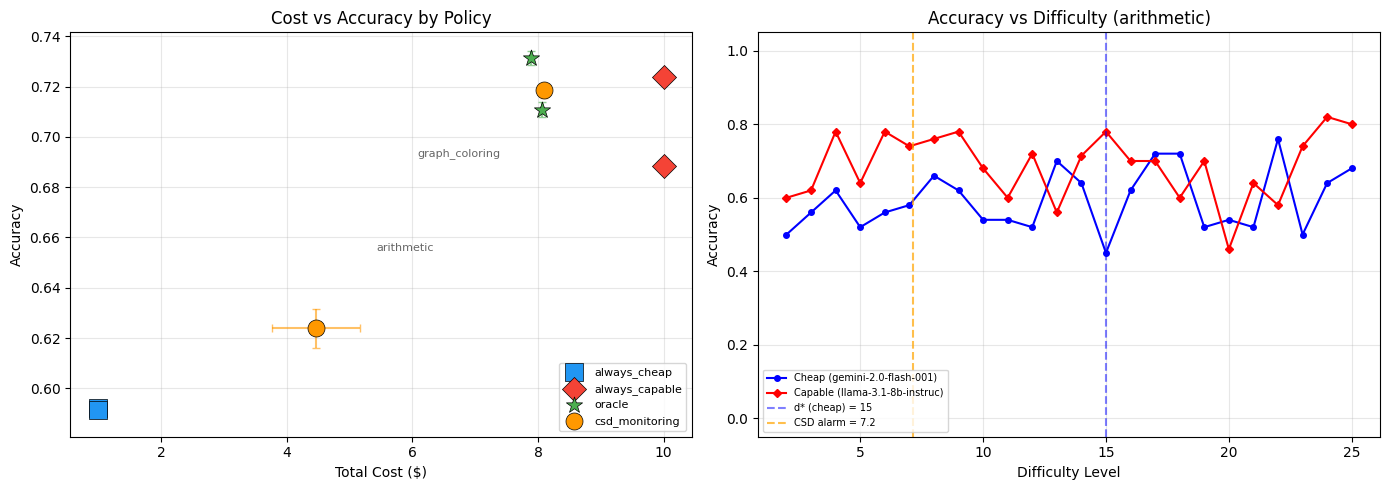

Saved routing_results.png


In [12]:
# ── Visualization: Cost vs Accuracy scatter + Accuracy by difficulty profile ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

policy_colors = {
    "always_cheap": "#2196F3",
    "always_capable": "#F44336",
    "oracle": "#4CAF50",
    "csd_monitoring": "#FF9800",
}
policy_markers = {
    "always_cheap": "s",
    "always_capable": "D",
    "oracle": "*",
    "csd_monitoring": "o",
}

# ── Left panel: Cost vs Accuracy for each task ──
ax = axes[0]
dist0 = DIFFICULTY_DISTRIBUTIONS[0]
batch0 = BATCH_SIZES[0]

for ti, (task_name, task_results) in enumerate(all_task_results.items()):
    pm = task_results[dist0][batch0]
    for p in POLICIES:
        m = pm[p]
        label = f"{p}" if ti == 0 else None
        ax.scatter(
            m["mean_cost"], m["mean_accuracy"],
            color=policy_colors[p], marker=policy_markers[p],
            s=150, edgecolors="black", linewidths=0.5, label=label, zorder=3,
        )
        # Error bars
        ax.errorbar(
            m["mean_cost"], m["mean_accuracy"],
            yerr=m["ci95_accuracy"], xerr=m["ci95_cost"],
            color=policy_colors[p], fmt="none", capsize=3, alpha=0.6,
        )
    # Task label
    mid_acc = np.mean([pm[p]["mean_accuracy"] for p in POLICIES])
    mid_cost = np.mean([pm[p]["mean_cost"] for p in POLICIES])
    ax.annotate(task_name, (mid_cost, mid_acc), fontsize=8,
                ha="center", va="bottom", alpha=0.6)

ax.set_xlabel("Total Cost ($)")
ax.set_ylabel("Accuracy")
ax.set_title("Cost vs Accuracy by Policy")
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.3)

# ── Right panel: Accuracy profile by difficulty level ──
ax = axes[1]
# Show accuracy curves for cheap vs capable for the first task
task0 = tasks[0]
cheap_data = task0["models"][task0["cheap"]]
capable_data = task0["models"][task0["capable"]]

cheap_levels_sorted = sorted(cheap_data["levels"].keys())
cap_levels_sorted = sorted(capable_data["levels"].keys())

cheap_accs = [cheap_data["levels"][d]["accuracy"] for d in cheap_levels_sorted]
cap_accs = [capable_data["levels"][d]["accuracy"] for d in cap_levels_sorted]

ax.plot(cheap_levels_sorted, cheap_accs, "b-o", markersize=4, label=f"Cheap ({task0['cheap'][:20]})")
ax.plot(cap_levels_sorted, cap_accs, "r-D", markersize=4, label=f"Capable ({task0['capable'][:20]})")

# Mark d* for cheap model
d_star = cheap_data["d_star"]
if d_star is not None:
    ax.axvline(d_star, color="blue", linestyle="--", alpha=0.5, label=f"d* (cheap) = {d_star}")

# Mark CSD alarm level if available
csd_m = all_task_results[task0["name"]][dist0][batch0]["csd_monitoring"]
if csd_m["mean_alarm_level"] > 0:
    ax.axvline(csd_m["mean_alarm_level"], color="orange", linestyle="--", alpha=0.7,
               label=f"CSD alarm = {csd_m['mean_alarm_level']:.1f}")

ax.set_xlabel("Difficulty Level")
ax.set_ylabel("Accuracy")
ax.set_title(f"Accuracy vs Difficulty ({task0['name']})")
ax.legend(fontsize=7, loc="lower left")
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig("routing_results.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved routing_results.png")